In [30]:
import numpy as np
import time
from numba import njit, prange
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Background Theory

## 1.2. Spatial Impulse Response (SIR) of far-field rectangular apertures : The Tupholme - Stephanishen approach.

Placing the rectangular aperture $ m $ of width and height $ w_{mx}, w_{my} $ in the $ x\text{-}y $ plane with its center at the coordinate $ \vec{r}_m $, the field point position vector—from the \( m \)-th rectangle to the \( p \)-th field point—is

$$
\vec{r}_{(m,p)} = \vec{r}_p - \vec{r}_m
$$

where $ \vec{r}_p $ are the coordinates of the field point. This vector can be further decomposed into a distance

$$
l_{(m,p)} = \| \vec{r}_{(m,p)} \|
$$

and a unit vector

$$
\vec{u}_{(m,p)} = \frac{\vec{r}_{(m,p)}}{\| \vec{r}_{(m,p)} \|} = (x_u, y_u, z_u)
$$

Using this description, one can get the following equations:

$$
\begin{align*}
t_1 &= \frac{l_{(m,p)}}{c_0} - \frac{\Delta t_1 + \Delta t_2}{2} \\
t_2 &= t_1 + \Delta t_1 \\
t_3 &= t_1 + \Delta t_2 \\
t_4 &= t_1 + \Delta t_1 + \Delta t_2 \tag{13}
\end{align*}
$$

Where $ \Delta t_1 $ and $ \Delta t_2 $ correspond to the minimum and maximum time-of-flight (TOF) for the side lengths of the rectangle:

$$
\Delta t_1 = \min\left(\frac{w_{my} y_u}{c_0}, \frac{w_{mx} x_u}{c_0}\right) \tag{14}
$$

$$
\Delta t_2 = \max\left(\frac{w_{my} y_u}{c_0}, \frac{w_{mx} x_u}{c_0}\right) \tag{15}
$$

Note that $ t_2 - t_1 = t_4 - t_3 = \Delta t_1 $ and $ t_3 - t_2 = \Delta t_2 - \Delta t_1 $, and that there are some cases where some of the $ t $'s are identical and thus have $ \Delta t_1 $ and/or $ \Delta t_2 $ equal to zero.

The shape of the trapezoid is a function of $ \Delta t_1 $ and $ \Delta t_2 $ and so is its amplitude, but the area of the trapezoid integrated over the whole time interval is always equal to:

$$
a_{rec}(l) = \frac{w_{mx} w_{my}}{2\pi l_{(m,p)}} \tag{16}
$$

Geometrically, the area can also be expressed as

$$
a_{rec} = h_{max} \Delta t_2 \tag{17}
$$

Combining (16) and (17) gives the trapezoid amplitude:

$$
h_{(m,p)}^{plateau} = \frac{w_{mx} w_{my}}{2\pi \Delta t_2 l_{(m,p)}} \tag{18}
$$

Then, the far-field trapezoidal SIR for an $ m $-th rectangular aperture is described by

$$
h_m(\vec{r}_p, t) = h(\vec{u}_{(m,p)}, l_{(m,p)}, w_{mx}, w_{my}, t) =
\begin{cases}
s_{(m,p)} (t - t_1), & t_1 < t < t_2 \\
h_{(m,p)}^{plateau}, & t_2 < t < t_3 \\
s_{(m,p)} (t_4 - t), & t_3 < t < t_4 \\
0, & \text{elsewhere}
\end{cases}
\tag{19}
$$

with

$$
s_{(m,p)} = \frac{h_{(m,p)}^{plateau}}{\Delta t_1} \tag{20}
$$

So, with the informations of the 5 parameteres we can compute all SIR of each small rectangle that composes the transducer. 
Now we are going to create a function to visualize the contribution of each small subdivision.


# 1.2. Computation of transducer SIR

The last trapezoidal SIR for each small rectangle is valid just if the subdivisions that are in far-field condition, then they must meet the next condition

$$
w \ll \sqrt{\frac{4 l c_0 }{f}} \tag{21}
$$

Where $l$ is the distance to the field point, $w$ the largest dimension of the rectangle and $f$ is the highest frequency in the response simulated. To have an idea, a field point at $0.5mm$ in water $c_0 = 1540mm$, and $f_c = 12.5Mhz$. Then the largest side of the rectangular aperture must be :

In [31]:
l = 0.5e-3 # m
c0 = 1540 # m/s
f = 12.5e6 # Hz
f_sampling = 200e6 # Hz

print(f"w << {np.sqrt(4*l*c0/f)*1e3:.2f} mm")
print(f"l_min = {32*(f/c0)*(c0/f_sampling)**2} mm")

w << 0.50 mm
l_min = 1.54e-05 mm



Thus, if this condition is guaranteed, thanks to the linearity assumption, we can obtain the next expression for the Transducer SIR shape.

$$
h_{tx}(\vec{r}_p, t) \approx \sum_{m=1}^{M} a_m \, h_m(\vec{r}_p, t - \tau_m) \tag{22}
$$

Where $h_m$ corresponds to the SIR showed in eq.[19], and $a_m, \tau_m$ corresponds to the apodization and delay applied to that specific patch. 
Therefore, to compute the transducer SIR, we need to add up each small patch $m$ SIR, of the $M$ patches making up the transducer.

## 2.3. The new method: Sparse Delta Integration SDI.

The naive method loops over the range of time where the trapezoidal piecewise function is defined, from $t_1$ to $t_4$, filling all non-zero trapezoid values per patch. In contrast, the proposed SDI method rewrites the trapezoid shape as the double integration of Dirac delta distributions—the complete development will be explained in the next subsection. This mathematical trick allows us, instead of looping over all time samples within $[t_1, t_4]$ for each patch, to compute only 8 sample points (for discrete implementation, 8 deltas are needed instead of 4) for all patches, at the expense of a double integration on time after looping all patches. To give a glimpse of the methods, the next GUI has as its objective to let you play with a simple trapezoid and the parameters that define it.

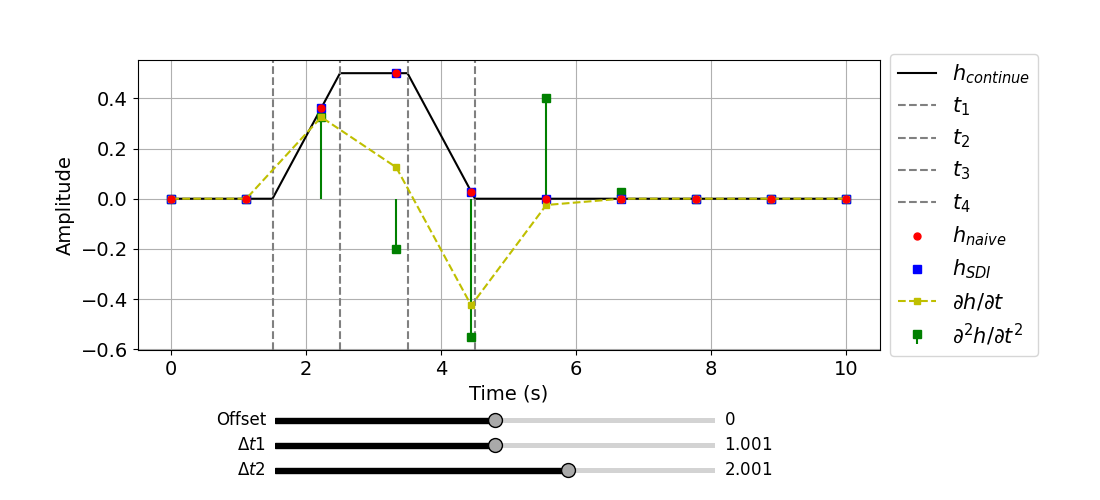

In [32]:
%matplotlib widget
from trapezoid_method_visualization import plot_trapezoid_methods

area = 1
l_c = 3

# Initial parameters and its range
Dt1 = 1
Dt2 = 2
shift = 0
range_Dt1 = (0.001, 2)
range_Dt2 = (0.001, 3)
range_shift = (-1, 1)

plot_trapezoid_methods(
    area, l_c, Dt1, Dt2, shift, range_Dt1, range_Dt2, range_shift
)


In [33]:
plt.close()
%matplotlib inline

# 2. Python implementation for computation of tx SIRs.

## 2.1. Creation of transducer object

To create the transducer, we are going to use some predefined functions from the package. If you are looking for more information on how to use and define transducer objects, please refer to the Tutorial_PyField.

Let's create a linear array with 128 elements and no subdivision to make it easier. 

In [34]:
import pyfield.transducers as transducers

# Settings

# Create transducer with elevation focus
# n_elements = 10
# kerf_mm = 1
# element_width_mm = 1
# element_height_mm = 1
# tx_freq = 12.5  # MHz
# elevation_focus_mm = 0 #8  # mm
# sub_x = 1
# sub_y = 1

n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5


kerf_mm = pitch_mm- element_width_mm 
tx_freq = 12.5  # MHz
elevation_focus_mm = 0 #8  # mm
sub_x = 1
sub_y = 1

# SIR Parameters
FoverD = 1
f_sampling = 200e6  # Hz
dt = 1 / f_sampling  # s
field_point_mm = np.array([[3, 0, 8]])  # mm
c = 1540  # speed of sound (m/s)


# ----------- Create the transducer -----------

MyTransducer = transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = kerf_mm,
    no_sub_x           = sub_x,
    no_sub_y           = sub_y,
    frequency_Hz       = tx_freq*1e6,  # MHz
    )



LinearArrayTransducer initialized in 0.0010 seconds.


Note that the patches have as size $w_x = 0.110$ and $w_y = 1.5$, the far-field condition of the trapezoidal spatial impulse response (SIR) needs

In [35]:
w = 1.5e-3 # m
lmin = tx_freq*1e6 * w**2 / (4 * c0)
print(f"l_min >> {lmin*1e3:.2f} mm")

l_min >> 4.57 mm


From the transducer object we compute all the patches geometrical information to be used on the computation of events (patches - field point trapezoid):

In [36]:
def compute_sub_elem_params(MyTransducer):
    centers, apods, delays = [], [], []
    for elem in range(MyTransducer.n_elements):
        for sub_elem in range(MyTransducer.no_sub_x * MyTransducer.no_sub_y):
            verts = MyTransducer.sub_quad_verts[
                elem * (MyTransducer.no_sub_x * MyTransducer.no_sub_y) + sub_elem
            ]
            centers.append(verts.mean(axis=0))
            apods.append(MyTransducer.apodization[elem])
            delays.append(MyTransducer.delays[elem])

    centers = np.array(centers, dtype=np.float32)  # shape (M, 3)
    apods = np.array(apods, dtype=np.float32)  # shape (M,)
    delays = np.array(delays, dtype=np.float32)  # shape (M,)
    return centers, apods, delays

events shape: (1, 128, 5)


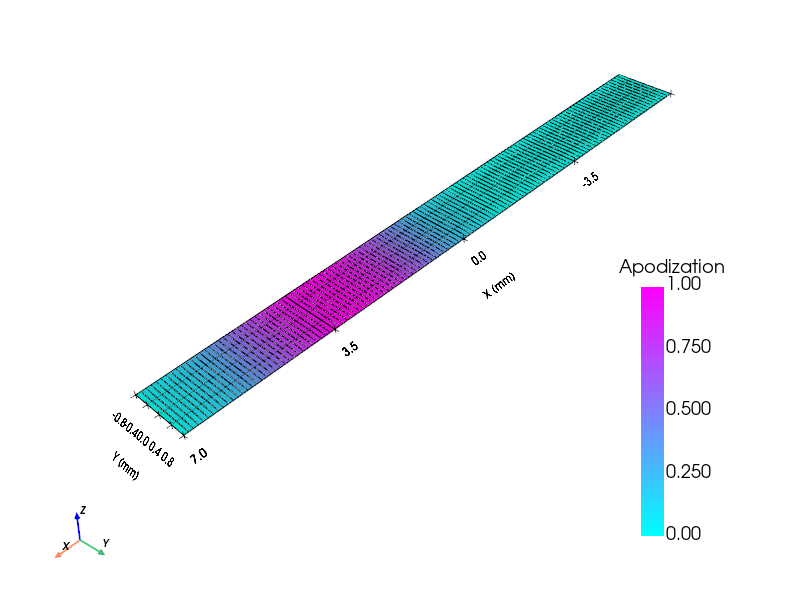

In [37]:
# Transducer geometry parameters
# Lets compute the patch parameters

wx = MyTransducer.elem_width  # element width (m)
wy = MyTransducer.elem_height  # element height (m)
# apodization and delays saved in the transducer object
apod_zeros = MyTransducer.apodization
delay_zeros = MyTransducer.delays

# compute the sub-element parameters
# with no apodization and delays (zeros)
centers, apods_sub_zeros, delays_sub_zeros = compute_sub_elem_params(MyTransducer)
# with apodization and delays
delay_focus = MyTransducer.compute_delays(focus_mm=field_point_mm)
apod_focus = MyTransducer.compute_apodization(focus_mm=field_point_mm, FoverD = FoverD, apodization_type='hamming')
centers, apods_sub_focus, delays_sub_focus = compute_sub_elem_params(MyTransducer)

# Let's compute the events for a single field point and all patches of the transducer
P = field_point_mm.shape[0]  # number of field points
M = centers.shape[0]  # number of patches

pts = field_point_mm * 1e-3  # (P,3) array of field points (m)
events_wo_apod_delays = np.zeros((P, M, 5), dtype=np.float32)  # (P,M,5) array of events
events_w_apod_delays = np.zeros((P, M, 5), dtype=np.float32)  # (P,M,5) array of events
print("events shape:", events_wo_apod_delays.shape)
MyTransducer.show(notebook = True, jupyter_backend='static')

## 2.2. Computation of trapezoid events (for visualization).

From the development showed in section 1, we define the function to compute the trapezoids.

In [38]:
inv_2pi = 1/(2*np.pi)

# ---------- small helper (njit) for rectangle SIR parameters ----------
@njit
def compute_rectangle_SIR_params(wx, wy, dx, dy, dist, inv_c, apod, delay, dt):
    """
    Return t1,t2,t3,t4,h_max (float32).
    dx,dy are direction cosines (xp, yp) used in your original compute.
    dist is distance from patch center to field point (float).
    inv_c is 1/c (float).
    """
    xp_abs = abs(dx) * wx * inv_c
    yp_abs = abs(dy) * wy * inv_c
    # enforce minimum to avoid zero width
    Dt1 = min(xp_abs, yp_abs)
    Dt2 = max(xp_abs, yp_abs)
    if Dt1 < dt:
        Dt1 = dt
    if Dt2 < dt:
        Dt2 = dt

    area = (wx * wy * inv_2pi) / dist
    # time-of-flight base
    t1 =  dist * inv_c - 0.5 * (Dt1 + Dt2) + delay
    t2 = t1 + Dt1
    t3 = t1 + Dt2
    t4 = t1 + Dt1 + Dt2
    h_max = area / Dt2 * apod

    return t1, t2, t3, t4, h_max

In [39]:
@njit(parallel=True)
def compute_all_events(P, M, pts, centers, wx, wy, c, apods, delays, events, dt):
    for p in prange(P):
        for i in range(M):
            dx = pts[p, 0] - centers[i, 0]
            dy = pts[p, 1] - centers[i, 1]
            dz = pts[p, 2] - centers[i, 2]
            dist = np.sqrt(dx * dx + dy * dy + dz * dz)

            xp, yp = dx / (dist), dy / (dist)
            t1, t2, t3, t4, h_max = compute_rectangle_SIR_params(
                wx,
                wy,
                xp,
                yp,
                dist,
                1/c,
                apods[i],
                delays[i],
                dt,
            )
            events[p, i, 0] = t1
            events[p, i, 1] = t2
            events[p, i, 2] = t3
            events[p, i, 3] = t4
            events[p, i, 4] = h_max

In [40]:
compute_all_events(P, M, pts, centers, wx, wy, c, apods_sub_zeros, delays_sub_zeros, events_wo_apod_delays, dt)
compute_all_events(P, M, pts, centers, wx, wy, c, apods_sub_focus, delays_sub_focus, events_w_apod_delays, dt)


And let's create a function to visualize how each event look like

In [41]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_SIR_events(events, y_subdiv, *, ax = None,title = None, cmap = None, add_cbar = True):

    if title is None :
        title = f'Contribution of each element to the field point at {field_point_mm[0]} mm'
    # Plot the contribution of each element to the field point

    # Add a colorbar
    n_elements = events.shape[1] // y_subdiv  # Correct calculation
    if cmap is None:
        cmap = plt.get_cmap('jet')
    else:
        cmap = plt.get_cmap(cmap)

    colors = cmap(np.linspace(0, 1, n_elements))
        
    flag_return_ax = True
    if ax is None:
        flag_return_ax = False
        fig, ax = plt.subplots(figsize=(14, 4))


    for i in range(n_elements):
        for j in range(y_subdiv): # loop over subdivisions in elevation
            m = j + i*y_subdiv
            t1, t2, t3, t4, h_max = events[0, m,:]
            ax.plot([t1*1e6, t2*1e6], [0, h_max], color=colors[i], lw=2, linestyle='solid')
            ax.plot([t2*1e6, t3*1e6], [h_max, h_max], color=colors[i], lw=2, linestyle='solid')
            ax.plot([t3*1e6, t4*1e6], [h_max, 0], color=colors[i], lw=2, linestyle='solid')
    ax.set_xlabel('$Time (µs)$')
    ax.set_ylabel('$h^{elem}_{SIR} (m/s)$')
    # ax.set_yscale('log')
    ax.set_title(title, loc='left')  # --- IGNORE ---
    ax.grid()

    if add_cbar:
        # Create colorbar as a legend inside the figure
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=n_elements))
        sm.set_array([])
        # Place the colorbar as an inset box (adjust location and size as needed)
        cax = inset_axes(ax, width="40%", height="8%", loc='upper right', borderpad=2)
        cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
        cbar.set_label('Element Index')
        cbar.set_ticks([0, n_elements//2, n_elements])
        cbar.set_ticklabels([0, n_elements//2, n_elements])
            
        cbar.ax.xaxis.set_label_position('top')

    if flag_return_ax:
        return ax

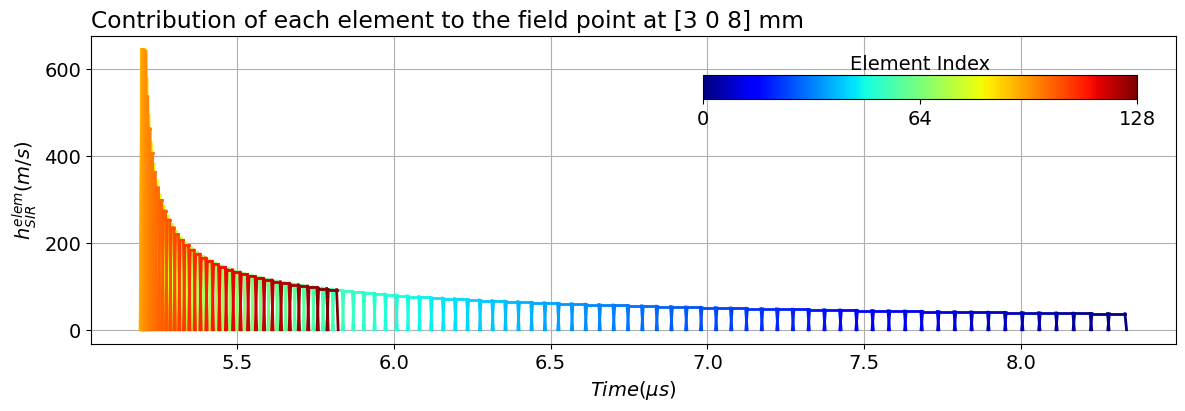

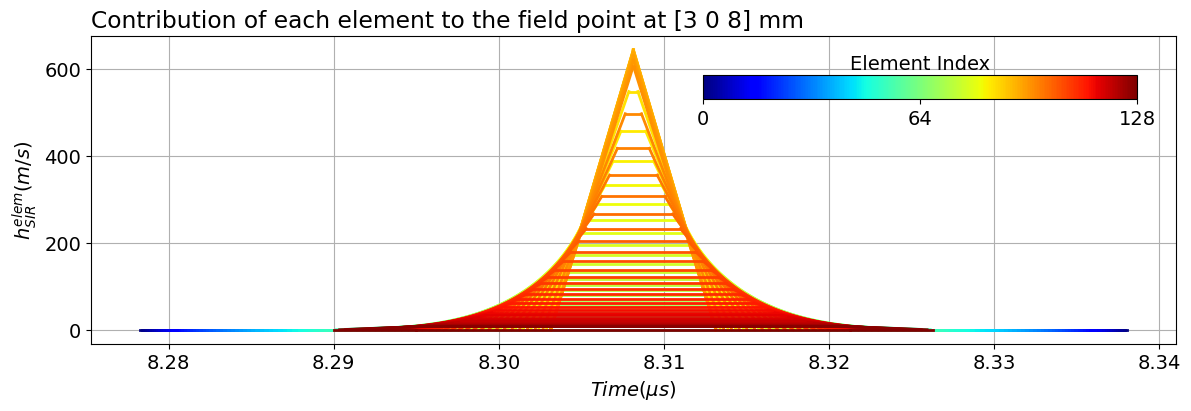

In [42]:
cmap = 'jet'

colormap = plt.get_cmap(cmap)

elem_colors = colormap(np.linspace(0, 1, n_elements))

plot_SIR_events(events_wo_apod_delays, sub_y, cmap = cmap)
plot_SIR_events(events_w_apod_delays, sub_y, cmap = cmap)


To compute the final shape of the transducers SIR, one need tu sum the contribution of each of the trapezoids showed in the last figure.

## 2.3. Methods for computation of tx SIR.

### 2.3.1. The Naive method:

The naive approach is the direct one, where one would loop over the timegrid vector to add for each point and patch the contributions. So the function would look as something like this.

In [43]:
# for a point p, element m, we have event = (t1, t2, t3, t4, h_max)
# we want to compute h_out[p, k] += h(t) where t = time_grid[k]
# and h(t) is the trapezoid defined by event
# k_start and k_end define the range of time samples to consider for this event

@njit
def naive_method(t1, t2, t3, t4, h_max, time_grid, h_out, p, k_start, k_end):
    slope = h_max / (t2 - t1)  # slope of rising and falling edges    

    # loop over every sample that might see part of this trapezoid
    for k in range(k_start, k_end):
        t = time_grid[k]
        # evaluate continuous trapezoid h(t)
        if t < t1 or t > t4:
            continue
        elif t < t2:
            h = slope * (t - t1) 
        elif t < t3:
            h = h_max
        else:
            h = slope * (t4 - t)

        # accumulate
        h_out[p, k] += h

### 2.3.2. Sparse Delta Integration (SDI)

From the derivation on equation [19], we can see that the first derivative of the trapezoid piecewise function can be written as follows:

$$
\frac{\partial h_m(\vec{r}_p, t)}{\partial t} =
\begin{cases}
s_{(m,p)}, & t_1 < t < t_2 \\
-s_{(m,p)}, & t_3 < t < t_4 \\
0, & \text{elsewhere}
\end{cases}
= s_{(m,p)} \cdot \left[ u(t-t_1) - u(t-t_2) - u(t-t_3) + u(t-t_4) \right]
\tag{24}
$$

Where $s_{(m,p)}$ is a function of the $m$-patch geometry and the field point $p$ as depicted in equation 20, and $u(t)$ is the Heaviside step function, defined as

$$
u(t) =
\begin{cases}
1, & t \geq 0 \\
0, & t < 0
\end{cases}
$$

If we continue with further derivation, we get the next expression:

$$
\frac{\partial^2 h_m(\vec{r}_p, t)}{\partial t^2} = s_{(m,p)} \cdot \left[ \delta(t-t_1) - \delta(t-t_2) - \delta(t-t_3) + \delta(t-t_4) \right] = s_{(m,p)} \Delta\delta(t)
\tag{25}
$$

Where $\delta(t)$ stands for the unit impulse or Dirac delta distribution, defined as

$$
\delta(t) =
\begin{cases}
1, & t = 0 \\
0, & t \neq 0
\end{cases}
$$
And

$$
\Delta\delta(t) = \delta(t-t_1) - \delta(t-t_2) - \delta(t-t_3) + \delta(t-t_4)
\tag{30}
$$

Thus, we can rewrite the piecewise function shown in [19] as

$$
h_{e,m}(\vec{r}_p, t) = \int_{-\infty}^{t}  \int_{-\infty}^{t'} s_{(m,p)} \Delta\delta(t'') \, dt''  dt'
\tag{26}
$$

Thanks to the additive property of the integrals, the SIR for a transducer composed of $M$ patches becomes

$$
h_{tx}(\vec{r}_p, t) \approx \sum_{m_e}^{M} a_e h_{e,m}(\vec{r}_p, t - \tau_e) = \int_{-\infty}^{t}  \int_{-\infty}^{t'} \left[\sum_{m_e}^{M}  a_e s_{(m,p)} \Delta\delta(t''  - \tau_e) \right] dt''  dt'
\tag{27}
$$


For implementation, the temporal axis must be discretized, which requires careful handling of the delta function contributions. The continuous variable $t$ is replaced by its sampled version $\{ t_k \}$, a vector of $T$ samples as defined in Eq. [24]. Unlike the piecewise trapezoidal function defined by the four times $(t_1, t_2, t_3, t_4)$, the reformulated method uses delta functions located exactly at these times. Since $t_1, \ldots, t_4$ do not necessarily coincide with the discrete grid $\{ t_k \}$, their contributions must be distributed to the closest discrete samples.

Intuitively, this means that instead of placing a delta “between samples” (which would be lost on the grid), we split its weight between the two nearest time samples. This ensures that the total contribution is preserved while being consistent with the discrete representation. Formally, for a continuous time $t'$ the fractional grid index is

$$
k_{t'} = \frac{t' - t_0}{dt}
\tag{28}
$$

and the interpolation weights are,

$$
w_{ceil}(t') = k_{t'} - \lfloor k_{t'} \rfloor, \qquad w^{floor}(t') = 1 - w_{ceil}(t')
\tag{29}
$$

Denoting by $t^f$ and $t^c$ the discrete times at the floor and ceil indices respectively (Eq. [37]), each delta contribution is mapped as a weighted pair of discrete impulses. Writing $\Delta\delta(t_k)$ for the discrete approximation of the continuous second-derivative impulses yields the floor/ceil decomposition
$$
\Delta\delta(t_k) = \Delta\delta(t_k)^{\text{ceil}} + \Delta\delta(t_k)^{\text{floor}}
\tag{31}
$$

With

$$
\Delta\delta(t_k)^{\text{floor}} = \sum_{t\in{t_1,t_2,t_3,t_4}} w_{floor}\bullet \Delta \delta(t_k-t^f)
\tag{32}
$$

$$
\Delta\delta(t_k)^{\text{ceil}} = \sum_{t\in{t_1,t_2,t_3,t_4}} w_{ceil}\bullet \Delta \delta(t_k-t^c)
\tag{33}
$$

This weighting ensures that the delta contributions are properly mapped onto the discrete time grid, by adding four more deltas.

In [44]:
# Precompute signs array for SDI method
signs = np.array((1.0,-1.0,-1.0,1.0), dtype=np.float32)

@njit
def sdi_method(t1, t2, t3, t4, h_max, d2h_out, t0, fs, T, p) :

    slope = h_max / (t2 - t1)  # slope of rising and falling edges    
    tis = np.array((t1,t2,t3,t4), dtype=np.float32)

    for idx in range(4):
        #Find real not integer sample index
        k_t = (tis[idx] - t0) * fs +1

        # Find the two nearest samples and their weights
        k_floor = int(np.floor(k_t))
        # Clamp k_floor to valid range
        # k_floor = max(0, min(k_floor, T-2))
        k_ceil = k_floor + 1

        if k_t < 0 or k_t > T-1:
            continue
        else:
            w_ceil = k_t - k_floor
            w_floor = 1 - w_ceil

            # Assign the weights to the two nearest samples
            d2h_out[p, k_floor] += signs[idx] * slope * w_floor
            d2h_out[p, k_ceil] += signs[idx] * slope * w_ceil

    return d2h_out


### 2.3.3. tx SIR: sum over events patch-points.

We now create a function that will accumulate the patchs' SIRs to build up the transducer one. To speed up the process, we use some python packages (Numba) that perform parallel computing on the CPU.

In [45]:
@njit(parallel=True, fastmath=True)
def compute_parallelized_sir(P, M, T, events, time_grid, fs, *, method = None):
    
    if method == "sdi":
        method_flag = 1
    else:
        method_flag = 0

    dt = 1.0 / fs
    t0 = time_grid[0]
    h_sir = np.zeros((P, T), dtype=np.float32)
    d2h_sdi = np.zeros((P, T), dtype=np.float32)
    dh_sdi = np.zeros((P, T), dtype=np.float32)
    range_k_matrix = np.zeros((P, M), dtype=np.int32)

    for p in prange(P):
        for i in prange(M):
            t1, t2, t3, t4, h_max = events[p, i,:]
            
            # Compute slope and k_start, k_end to fill the trapezoid
            k_start = int(np.floor((t1 - t0) * fs))
            k_end = int(np.ceil((t4 - t0) * fs) + 1)

            # clamp to valid range
            if k_start < 0 or k_end > T-1:
                continue

            range_k = k_end - k_start
            range_k_matrix[p , i] = range_k

            # Choose method based on range_k
            if method_flag == 0:  # naive
                naive_method(t1, t2, t3, t4, h_max, time_grid, h_sir, p, k_start, k_end)
            elif method_flag == 1:  # sdi
                sdi_method(t1, t2, t3, t4, h_max, d2h_sdi, t0, fs, T, p)
            else:  
                raise ValueError("method_flag must be 0 (naive) or 1 (sdi)")
    
        # After all patches for point p processed, if any SDI events were added, integrate
        # We must integrate d2h -> dh -> h and add to h_out
        # (Even if some patches used naive, we still need to add integrated d2h)
        # First cumulative sum (in-place on a temp)

        if method_flag != 0:  # if not purely naive
            acc = 0.0
            for k in range(T):
                acc += d2h_sdi[p, k]
                dh_sdi[p, k] = acc
                # We dont multiply by dt because delta is a point.
            acc2 = 0.0
            for k in range(T):
                acc2 += dh_sdi[p, k]
                # multiply by dt once to match continuous integral scaling
                h_sir[p, k] += acc2 * dt

    return h_sir, d2h_sdi, range_k_matrix

### 2.3.4. Comparison Naive and SDI.

Now that we have created this function to accumulate the results of both methods let's use it.

In [46]:
# You need to have run the previous cells to define the parameters

all_times_w = events_w_apod_delays[:, :, 0:4]
all_times_wo = events_wo_apod_delays[:, :, 0:4]
t0 = min(all_times_w.min(), all_times_wo.min())
tN = max(all_times_w.max(), all_times_wo.max())
t0 = t0 * 0.8  # start a bit before the first
tN = tN * 1.2  # end a bit after the last

t0 = min(t0, 0)  # Ensure t0 is not positive

# Define time grid
min_time_samples = int(np.ceil((tN - t0) * f_sampling))
# next power of two
T = 2 ** max(int(np.ceil(np.log2(min_time_samples))), 5) # compute the next power of two, minimum 32 time samples
time_grid = t0 + np.arange(0, T) * dt  # start a bit before the first

print(f"Time samples: {T}, from {t0*1e6:.2f} us to {time_grid[-1]*1e6:.2f} us, dt = {dt*1e6:.2f} us")

# Check the function and prepare the kernels for computation
h1_naive,d2h, range1_k_matrix = compute_parallelized_sir(P, M, T, events_w_apod_delays, time_grid, f_sampling, method="naive")


Time samples: 2048, from 0.00 us to 10.23 us, dt = 0.01 us


c:\Users\INSERM\Documents\Esteban\PyField\.venv\Lib\site-packages\numba\parfors\parfor.py:2395: NumbaPerformanceWarning: 
prange or pndindex loop will not be executed in parallel due to there being more than one entry to or exit from the loop (e.g., an assertion).

File "..\..\..\..\AppData\Local\Temp\ipykernel_1936\3494251527.py", line 17:
<source missing, REPL/exec in use?>

  warnings.warn(
c:\Users\INSERM\Documents\Esteban\PyField\.venv\Lib\site-packages\numba\parfors\parfor.py:2395: NumbaPerformanceWarning: 
prange or pndindex loop will not be executed in parallel due to there being more than one entry to or exit from the loop (e.g., an assertion).

File "..\..\..\..\AppData\Local\Temp\ipykernel_1936\3494251527.py", line 16:
<source missing, REPL/exec in use?>

  warnings.warn(


In [47]:

# Compute the acumulated SIR using naive method
start_naive = time.time()
h1_naive, d2h1, range1_k_matrix = compute_parallelized_sir(P, M, T, events_wo_apod_delays, time_grid, f_sampling, method="naive")
end_naive = time.time() 
h2_naive, d2h2, range2_k_matrix = compute_parallelized_sir(P, M, T, events_w_apod_delays, time_grid, f_sampling, method="naive")
print(f"Naive method took {end_naive-start_naive:.4f} seconds")

start_sdi = time.time()
h1_sdi, d2h1, _ = compute_parallelized_sir(P, M, T, events_wo_apod_delays, time_grid, f_sampling, method="sdi")
end_sdi = time.time() 
h2_sdi, d2h2, _ = compute_parallelized_sir(P, M, T, events_w_apod_delays, time_grid, f_sampling, method="sdi")
print(f"SDI method took {end_sdi - start_sdi:.4f} seconds")


Naive method took 0.0000 seconds
SDI method took 0.0000 seconds


In [48]:
def plot_SIR_tx(time_grid, h_sir, *, ax = None, title = None, **kwargs):
    # Plot the contribution of each element to the field point
    
    flag_return_ax = True
    if ax is None:
        flag_return_ax = False
        fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(time_grid*1e6, h_sir[0], **kwargs)

    ax.set_xlabel('$Time (µs)$')
    ax.set_ylabel('$h^{tx}_{SIR} (m/s)$')
    # ax.set_yscale('log')
    ax.set_title(title, loc = 'left')  # --- IGNORE ---
    ax.grid('minor')

    if flag_return_ax:
        return ax

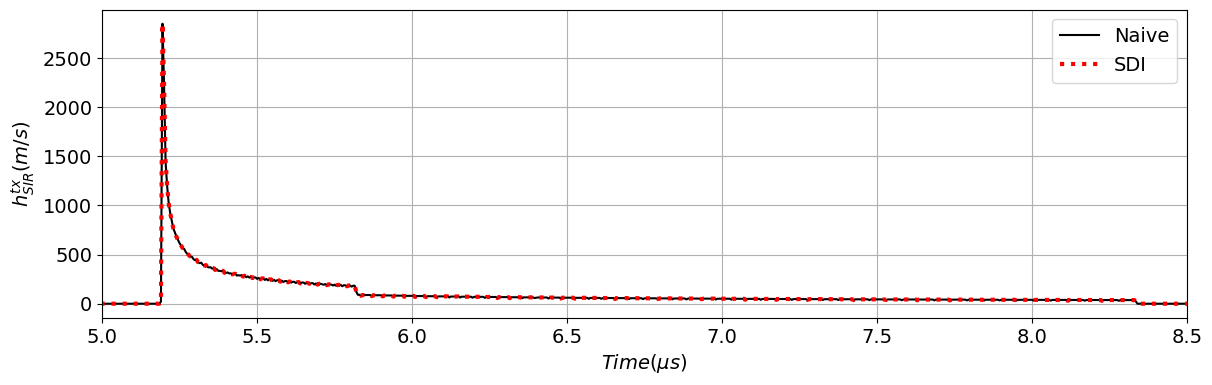

In [49]:
fig, ax = plt.subplots(figsize=(14, 4))
ax= plot_SIR_tx(time_grid, h1_naive, ax = ax, color = 'k',lw=1.5, label = 'Naive', linestyle = 'solid')
ax = plot_SIR_tx(time_grid, h1_sdi, ax = ax, color = 'red',lw=3, label = 'SDI', linestyle = 'dotted')
ax.set_xlim([5,8.5])
ax.legend()

C:\Users\INSERM\AppData\Local\Temp\ipykernel_1936\3037017374.py:3: RuntimeWarning: divide by zero encountered in log10
  log_A = np.log10(np.abs(A))
C:\Users\INSERM\AppData\Local\Temp\ipykernel_1936\3037017374.py:5: RuntimeWarning: invalid value encountered in multiply
  return np.squeeze(signs * log_A)


Text(0.0, 1.0, 'SDI deltas (second derivative h_sir)')

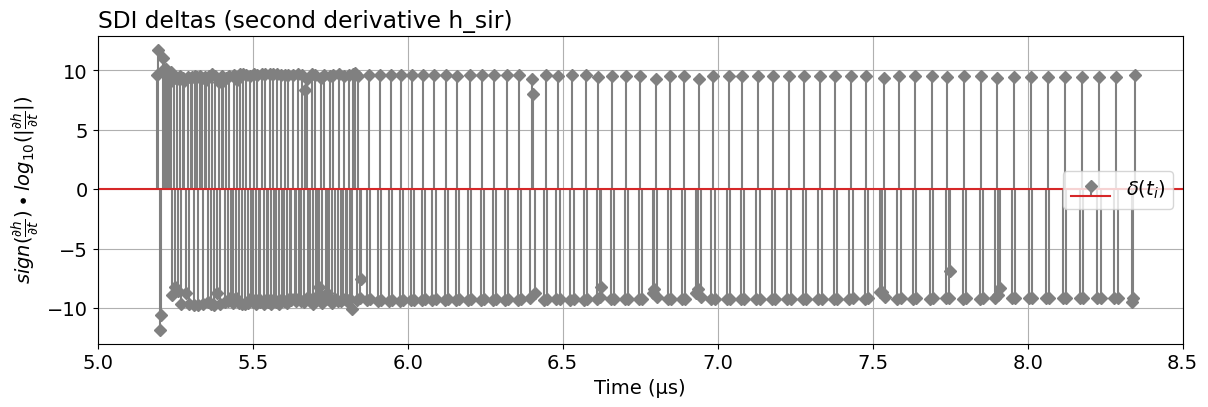

In [50]:
def log_custom(A):
    signs = np.sign(A)
    log_A = np.log10(np.abs(A))
    # log_A[A==0] = 0
    return np.squeeze(signs * log_A)

fig, ax = plt.subplots(figsize=(14, 4))
# use ax.stem so ax remains an Axes; multiply time_grid by 1e6 to plot µs
ax.stem(time_grid * 1e6, log_custom(d2h1), label=r'$\delta (t_i)$', linefmt='gray', markerfmt='D')
ax.set_xlim([5, 8.5])
ax.set_xlabel('Time (µs)')
ax.set_ylabel(r'$sign(\frac{\partial h}{\partial t}) \bullet log_{10}(|\frac{\partial h}{\partial t}|)$')
ax.grid(True)
ax.legend()
ax.set_title('SDI deltas (second derivative h_sir)', loc = 'left')

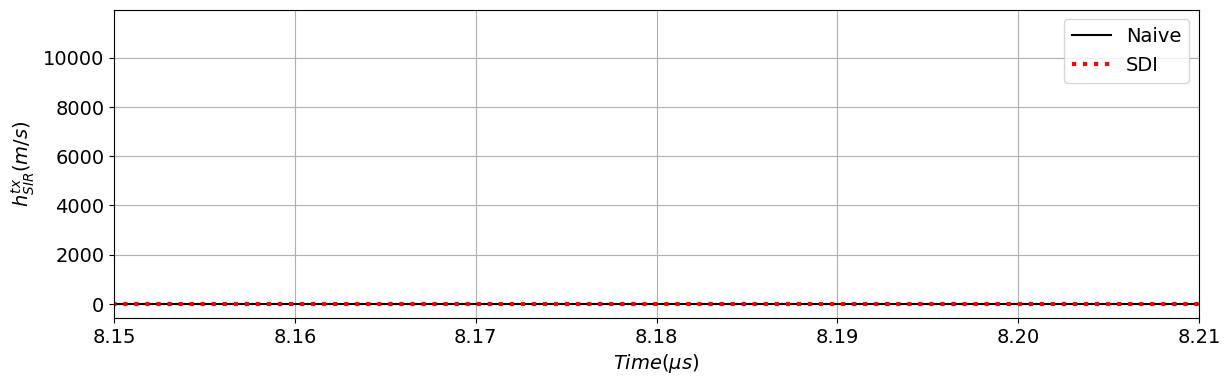

In [51]:
fig, ax = plt.subplots(figsize=(14, 4))
ax= plot_SIR_tx(time_grid, h2_naive, ax = ax, color = 'k',lw=1.5, label = 'Naive', linestyle = 'solid')
ax = plot_SIR_tx(time_grid, h2_sdi, ax = ax, color = 'red',lw=3, label = 'SDI', linestyle = 'dotted')
ax.set_xlim([8.15, 8.21])
ax.legend()

## 2.3.5. Final visualization

Let's make an all in one graph

In [52]:
# Create elements
def plot_transducer_elements_plane(centers, element_width_mm, element_height_mm, *,cmap = 'jet', ax = None, title = None):

    colors = plt.get_cmap(cmap)(np.linspace(0, 1, centers.shape[0]))
    flag_return_ax = True
    if ax is None:
        flag_return_ax = False
        fig, ax = plt.subplots(figsize=(10, 2))

    n_elements = centers.shape[0]
    for i in range(n_elements):
        x_left = centers[i, 0]*1e3 - element_width_mm/2
        x_right = centers[i, 0]*1e3 + element_width_mm/2
        y_up = centers[i, 1]*1e3 + element_height_mm/2
        y_down = centers[i, 1]*1e3 - element_height_mm/2
        x_elem = [x_left, x_right, x_right, x_left, x_left]
        y_elem = [y_down, y_down, y_up, y_up, y_down]
        ax.fill(x_elem, y_elem, alpha=0.7, color=colors[i])
        ax.plot(x_elem, y_elem, color='black', lw=0.5)

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(title, loc='left')
    ax.axis('equal')
    ax.grid()

    if flag_return_ax:
        return ax
    

# make a function to plot the transducers delays and apodization
def plot_delays_colored_with_apodization(delays, apodization, *, ax=None, title=None, add_cbar = True):
    if title is None:
        title = 'Transducer delays and apodization'
    flag_return_ax = True
    if ax is None:
        flag_return_ax = False
        fig, ax = plt.subplots(figsize=(10, 4))

    n_elements = delays.shape[0]
    cmap = plt.get_cmap('cool')
    norm = plt.Normalize(vmin=0, vmax=1)
    colors = cmap(norm(apodization))

    # Scatter plot with color-coded apodization
    ax.plot(range(n_elements), delays*1e6, 'k-', zorder = 1)
    sc = ax.scatter(range(n_elements), delays*1e6, c=apodization, cmap=cmap, norm=norm, s=40, label='Delay')
    ax.set_xlabel('Element Index')
    ax.set_ylabel('Delay (µs)')
    ax.set_title(title, loc='left')  # --- IGNORE ---
    ax.grid()

    # Add colorbar as legend for apodization
    if add_cbar:
        cax = inset_axes(ax, width="40%", height="8%", loc='lower right', borderpad=2)
        cbar = plt.colorbar(sc, cax=cax, orientation='horizontal')
        cbar.set_label('Apodization')
        cbar.set_ticks([0, 0.5, 1])
        cbar.set_ticklabels(['0', '0.5', '1'])

        # Move the label above the colorbar
        cbar.ax.xaxis.set_label_position('top')
        cbar.ax.xaxis.set_ticks_position('bottom')
    if flag_return_ax:
        return ax

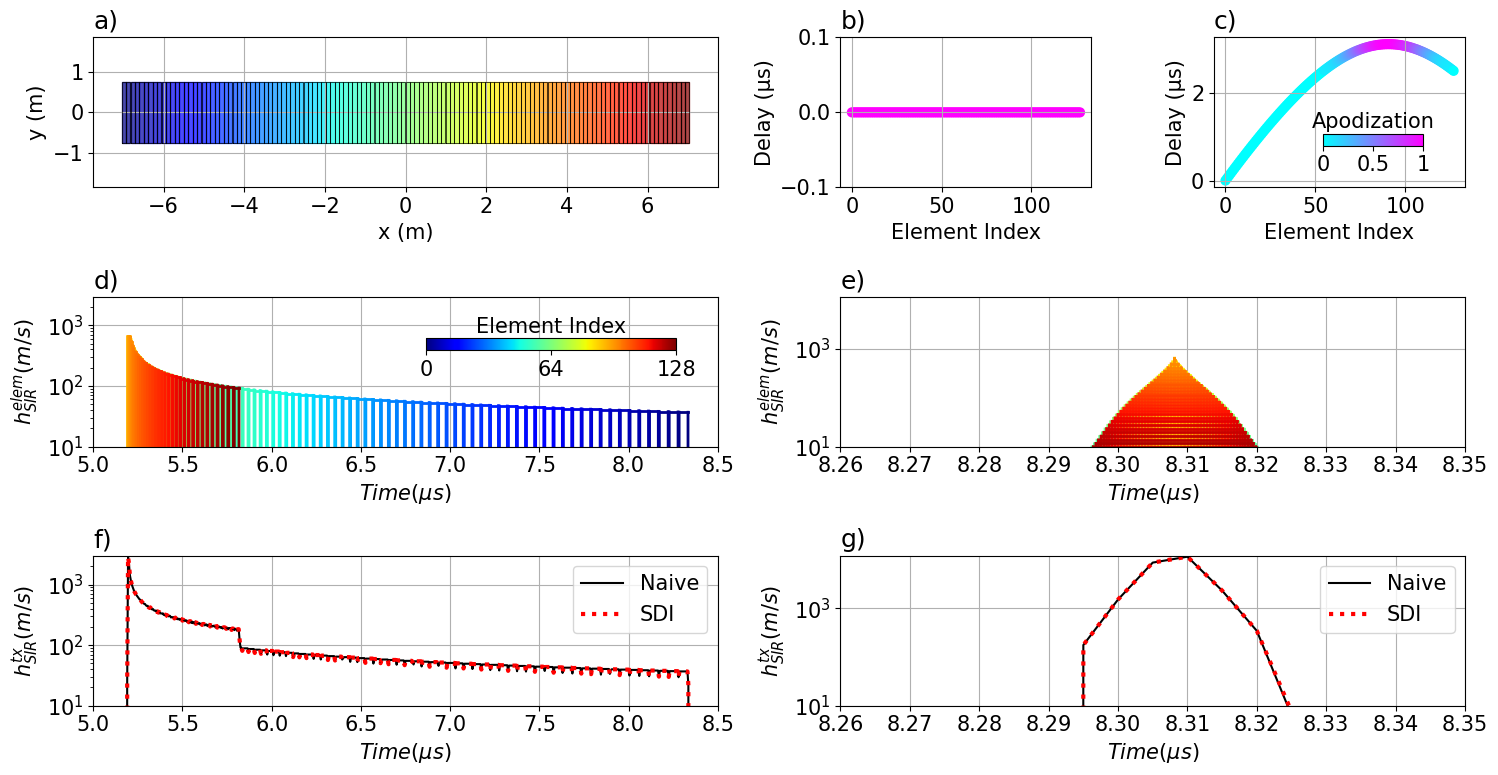

In [60]:
# Use matplotlib.gridspec to span plots across multiple columns
import matplotlib.gridspec as gridspec

# plt.style.use("seaborn-v0_8")
plt.rcParams.update({"font.size": 15})
plt.rcParams["font.weight"] = "normal"

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(3, 4, figure=fig)

# a) Transducer elements plane (span 2 columns)
ax_a = fig.add_subplot(gs[0, 0:2])
plot_transducer_elements_plane(centers, element_width_mm, element_height_mm, ax=ax_a, title='a)')

# b) Delays/apodization (no focus)
ax_b = fig.add_subplot(gs[0, 2])
plot_delays_colored_with_apodization(delay_zeros, apod_zeros, ax=ax_b, title='b)', add_cbar = False)
ax_b.set_ylim([-0.1, 0.1])

# c) Delays/apodization (focus)
ax_c = fig.add_subplot(gs[0, 3])
plot_delays_colored_with_apodization(delay_focus, apod_focus, ax=ax_c, title='c)')

# d) SIR events (no apod/delay), span 2 columns
ax_d = fig.add_subplot(gs[1, 0:2])
plot_SIR_events(events_wo_apod_delays, sub_y, ax=ax_d, title='d)', cmap=cmap)
ax_d.set_xlim([5, 8.5])
ax_d.set_yscale('log')
ax_d.set_ylim([10, h1_sdi.max()*1.05])
ax_d.grid('minor')

# e) SIR events (with apod/delay), span 2 columns
ax_e = fig.add_subplot(gs[1, 2:4])
plot_SIR_events(events_w_apod_delays, sub_y, ax=ax_e, title='e)', cmap=cmap, add_cbar= False)
ax_e.set_xlim([8.26, 8.35])
ax_e.set_yscale('log')
ax_e.set_ylim([10, h2_sdi.max()*1.05])
ax_e.grid('minor')

# f) SIR tx (no apod/delay), span 2 columns
ax_f = fig.add_subplot(gs[2, 0:2])
plot_SIR_tx(time_grid, h1_naive, ax=ax_f, color='k', lw=1.5, label='Naive', linestyle='solid')
plot_SIR_tx(time_grid, h1_sdi, ax=ax_f, color='red', lw=3, label='SDI', linestyle='dotted', title='f)')
ax_f.set_xlim([5, 8.5])
ax_f.set_yscale('log')
ax_f.set_ylim([10, h1_sdi.max()*1.05])
ax_f.legend()

# g) SIR tx (with apod/delay), span 2 columns
ax_g = fig.add_subplot(gs[2, 2:4])
plot_SIR_tx(time_grid, h2_naive, ax=ax_g, color='k', lw=1.5, label='Naive', linestyle='solid')
plot_SIR_tx(time_grid, h2_sdi, ax=ax_g, color='red', lw=3, label='SDI', linestyle='dotted', title='g)')
ax_g.set_xlim([8.26, 8.35])
ax_g.set_yscale('log')
ax_g.set_ylim([10, h2_sdi.max()*1.05])
ax_g.legend()

plt.tight_layout()

# 3. PyField

A better version of the methods where implemented in the class PyField. The code in PyField is made to be parallelized in CPU and avoid overhead on methods codes, so a fair comparison could be made.

## 3.1. Linear transducer array

### 3.1.1. Definition of transducer object

In [54]:
import pyfield
from pyfield.transducers import Domino, Zeus_Matrix
from pyfield.psimulation import PyField

focus_mm = np.array([-2, 0, 8])
FoverD = 1


LinearArrayTransducer initialized in 0.0000 seconds.


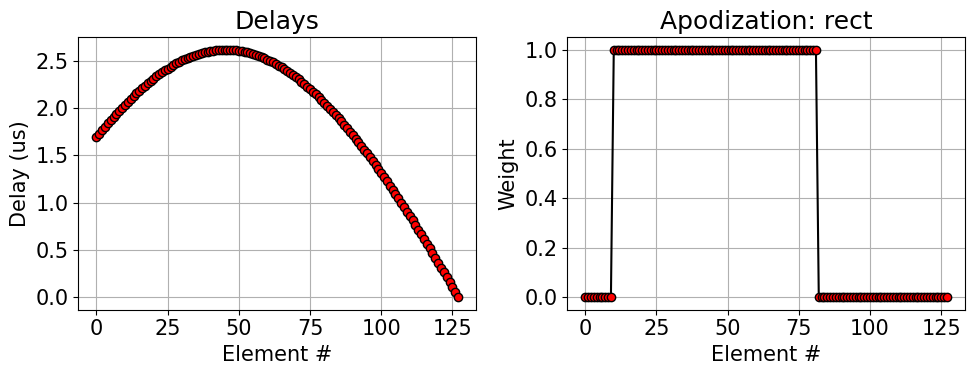

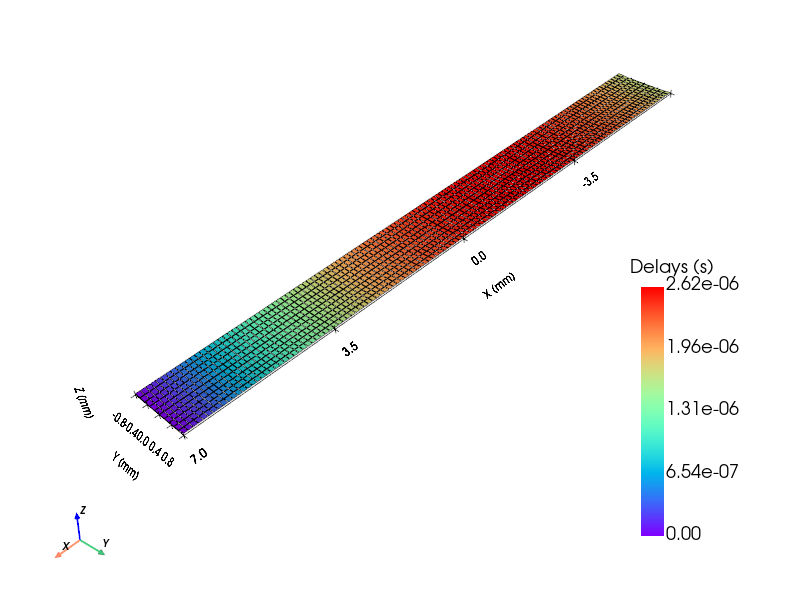

In [55]:
linear_array_probe = Domino()

delays = linear_array_probe.compute_delays(focus_mm=focus_mm)
apodization = linear_array_probe.compute_apodization( 
    focus_mm=focus_mm, FoverD=1)
linear_array_probe.plot_delays_apodization()
linear_array_probe.show(notebook=True, jupyter_backend='static', scalars = 'Delays')



### 3.1.2. Compute pressure field

In [521]:
x_half_size_mm = 0.25
y_half_size_mm = 0.5
z_half_size_mm = 1.5
x_extent_mm = [-x_half_size_mm+focus_mm[0], x_half_size_mm+focus_mm[0]]
y_extent_mm = [-y_half_size_mm+focus_mm[1], y_half_size_mm+focus_mm[1]]
z_extent_mm = [-z_half_size_mm +focus_mm[2], z_half_size_mm+focus_mm[2]]
dx_mm = 0.015
dy_mm = 0.02
dz_mm = 0.05


x = np.linspace(x_extent_mm[0], x_extent_mm[1], int((x_extent_mm[1]-x_extent_mm[0])/dx_mm)+1)
y = np.linspace(y_extent_mm[0], y_extent_mm[1], int((y_extent_mm[1]-y_extent_mm[0])/dy_mm)+1)
z = np.linspace(z_extent_mm[0], z_extent_mm[1], int((z_extent_mm[1]-z_extent_mm[0])/dz_mm)+1)
field_point_mm = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)
print(f"Number of field points: {field_point_mm.shape[0]}, and x.shape: {x.shape}, y.shape: {y.shape}, z.shape: {z.shape}")
print(f"Field points from {field_point_mm.min(axis=0)} mm to {field_point_mm.max(axis=0)} mm")

Number of field points: 105774, and x.shape: (34,), y.shape: (51,), z.shape: (61,)
Field points from [-2.25 -0.5   6.5 ] mm to [-1.75  0.5   9.5 ] mm


In [522]:
# The first call to the PyField object will take some time to prepare 
# the parallel computation and compile the numba kernels,
# but subsequent calls will be much faster.
linear_field = PyField(linear_array_probe)
x0, y0, z0, p_linearfield0 = linear_field(field_point_mm, method = 'auto')

Min distance must be >> w^2/(4*lambda): 0.0457 mm

Computing SIR for 105774 points and 1280 patches with method auto...
Min distance: 6.47 mm, Max distance: 13.28 mm
Computed time grid from 4.12 us to 11.32 us, with 1441 samples in 1.09 seconds.
Transducer SIR computed in 6.640 seconds...
Pressure computed from SIR in 0.82 seconds...
Pressure field computed in 7.52 seconds... 



In [523]:
x1, y1, z1, p_linearfield1 = linear_field(field_point_mm, method = 'naive')


Computing SIR for 105774 points and 1280 patches with method naive...
Min distance: 6.47 mm, Max distance: 13.28 mm
Computed time grid from 4.12 us to 11.32 us, with 1441 samples in 0.04 seconds.
Transducer SIR computed in 3.457 seconds...
Pressure computed from SIR in 0.82 seconds...
Pressure field computed in 4.34 seconds... 



In [524]:
x2, y2, z2, p_linearfield2 = linear_field(field_point_mm, method = 'sdi')


Computing SIR for 105774 points and 1280 patches with method sdi...
Min distance: 6.47 mm, Max distance: 13.28 mm
Computed time grid from 4.12 us to 11.32 us, with 1441 samples in 0.05 seconds.
Transducer SIR computed in 0.443 seconds...
Pressure computed from SIR in 0.83 seconds...
Pressure field computed in 1.34 seconds... 



In [525]:
x3, y3, z3, p_linearfield3 = linear_field(field_point_mm, method = 'auto')


Computing SIR for 105774 points and 1280 patches with method auto...
Min distance: 6.47 mm, Max distance: 13.28 mm
Computed time grid from 4.12 us to 11.32 us, with 1441 samples in 0.05 seconds.
Transducer SIR computed in 0.502 seconds...
Pressure computed from SIR in 0.81 seconds...
Pressure field computed in 1.38 seconds... 



Taking slice (-1.9924242424242424,0.0,8.0) => x_ind, y_ind, z_ind = 18/34, 26/51, 31/61


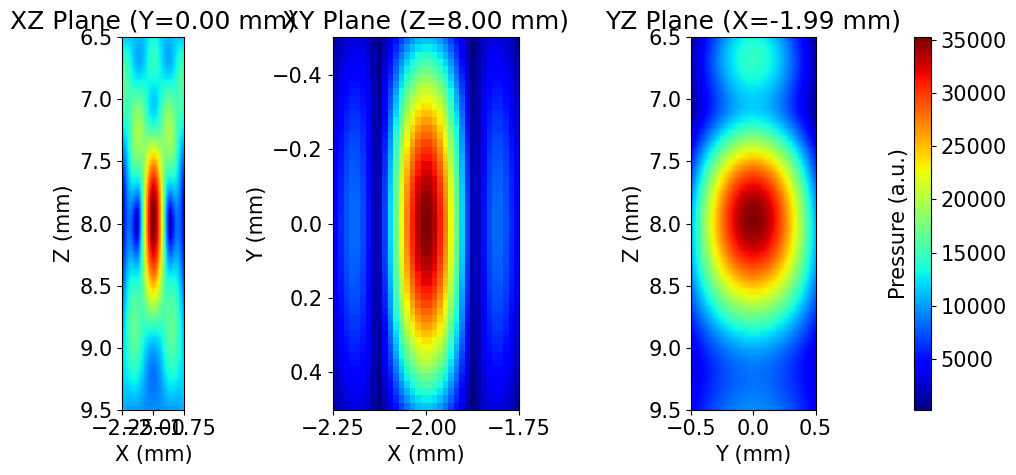

Taking slice (-1.9924242424242424,0.0,8.0) => x_ind, y_ind, z_ind = 18/34, 26/51, 31/61


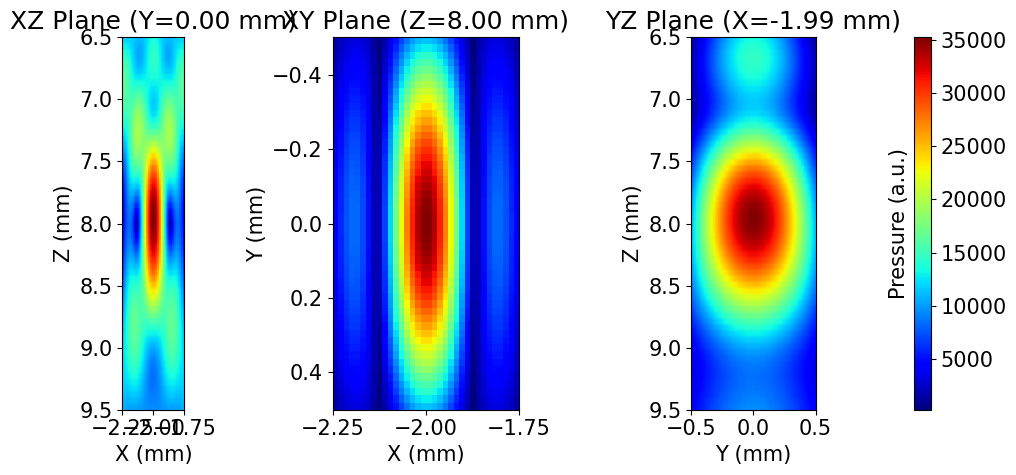

Taking slice (-1.9924242424242424,0.0,8.0) => x_ind, y_ind, z_ind = 18/34, 26/51, 31/61


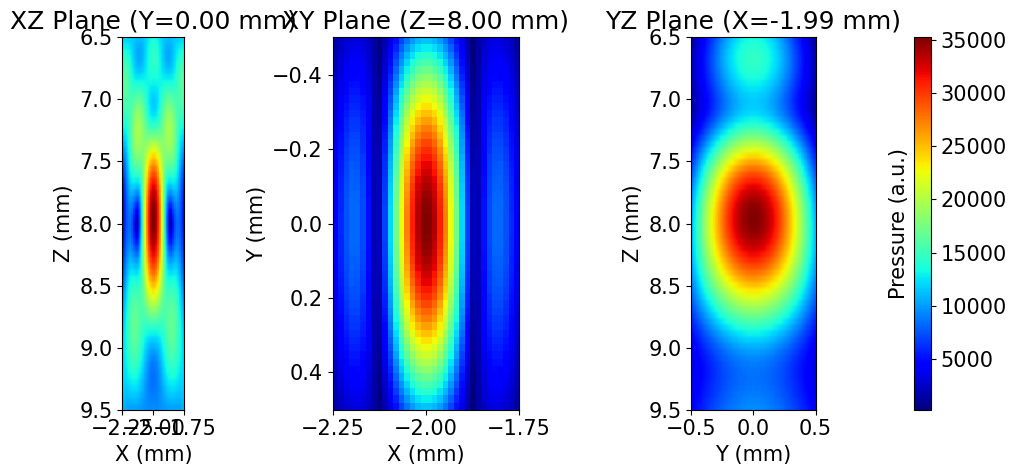

In [526]:
pyfield.plot_field_planes(x1, y1, z1,p_linearfield1)
pyfield.plot_field_planes(x2, y2, z2,p_linearfield2)
pyfield.plot_field_planes(x3, y3, z3,p_linearfield3)

## 3.2. Matrix transducer

### 3.2.1. Definition of transducer object

MatrixArrayTransducer initialized with 3025 elements and 12100 patches.

Transducer initialized in 0.0646 seconds.


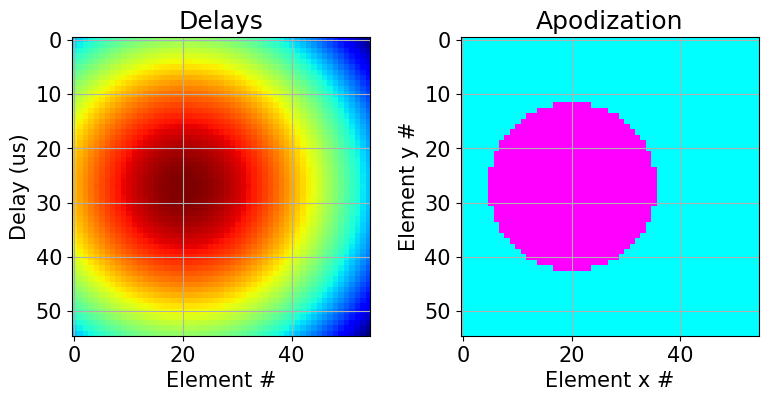

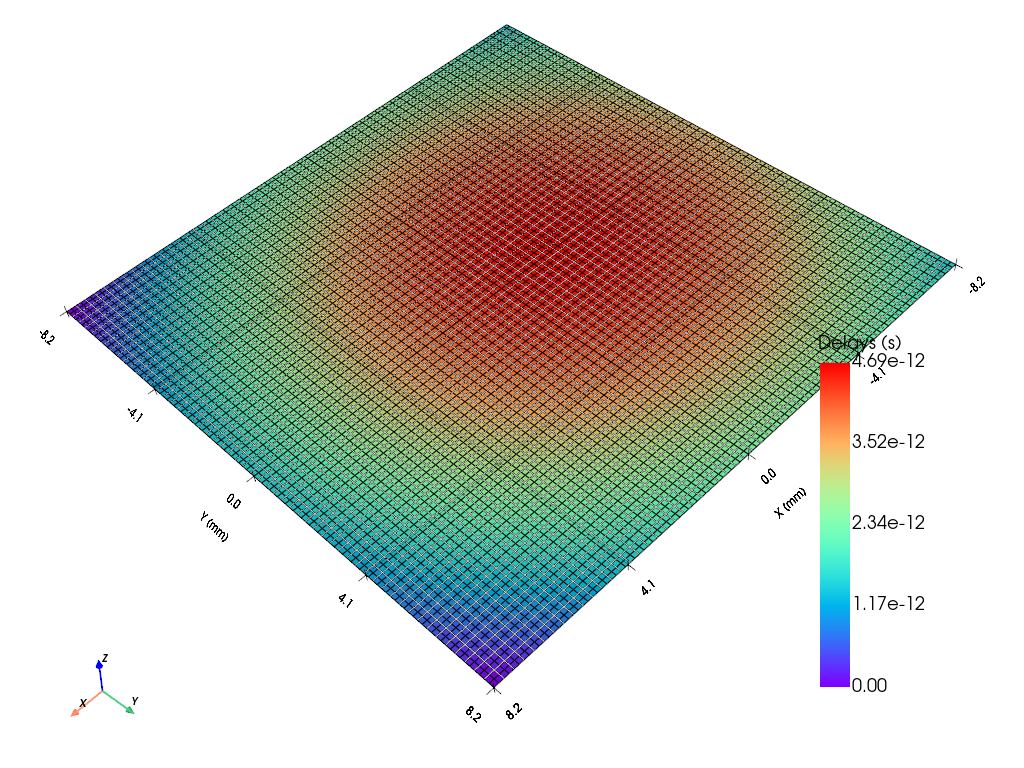

In [527]:
matrix_array_probe = Zeus_Matrix()

delays = matrix_array_probe.compute_delays(focus_mm=focus_mm)
apodization = matrix_array_probe.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD)
matrix_array_probe.plot_delays_apodization()
matrix_array_probe.show(notebook=True, jupyter_backend='static', scalars = "Delays")


### 3.2.2. Compute pressure field

In [528]:
x_half_size_mm = 0.25
y_half_size_mm = 0.5
z_half_size_mm = 1.5
x_extent_mm = [-x_half_size_mm+focus_mm[0], x_half_size_mm+focus_mm[0]]
y_extent_mm = [-y_half_size_mm+focus_mm[1], y_half_size_mm+focus_mm[1]]
z_extent_mm = [-z_half_size_mm +focus_mm[2], z_half_size_mm+focus_mm[2]]
dx_mm = 0.015
dy_mm = 0.02
dz_mm = 0.05

# x_extent_mm = [-x_half_size_mm+focus_mm[0], x_half_size_mm+focus_mm[0]]
# y_extent_mm = [-y_half_size_mm+focus_mm[1], y_half_size_mm+focus_mm[1]]
# z_extent_mm = [-z_half_size_mm +focus_mm[2], z_half_size_mm+focus_mm[2]]
# dx_mm = 0.03
# dy_mm = 0.03
# dz_mm = 0.05

x = np.linspace(x_extent_mm[0], x_extent_mm[1], int((x_extent_mm[1]-x_extent_mm[0])/dx_mm)+1)
y = np.linspace(y_extent_mm[0], y_extent_mm[1], int((y_extent_mm[1]-y_extent_mm[0])/dy_mm)+1)
z = np.linspace(z_extent_mm[0], z_extent_mm[1], int((z_extent_mm[1]-z_extent_mm[0])/dz_mm)+1)
field_info_mm = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)
print(f"Number of field points: {field_info_mm.shape[0]}, x.shape: {x.shape}, y.shape: {y.shape}, z.shape: {z.shape}")
print(f"Field points from {field_info_mm.min(axis=0)} mm to {field_info_mm.max(axis=0)} mm")

Number of field points: 105774, x.shape: (34,), y.shape: (51,), z.shape: (61,)
Field points from [-2.25 -0.5   6.5 ] mm to [-1.75  0.5   9.5 ] mm


In [529]:
matrix_field = PyField(matrix_array_probe)
x3, y3, z3, p_matrixfield3 = matrix_field(field_info_mm, method = 'auto')

Min distance must be >> w^2/(4*lambda): 0.0341 mm

Computing SIR for 105774 points and 12100 patches with method auto...
Min distance: 6.50 mm, Max distance: 16.56 mm
Computed time grid from 4.13 us to 15.53 us, with 2282 samples in 0.31 seconds.
Transducer SIR computed in 2.147 seconds...
Pressure computed from SIR in 1.31 seconds...
Pressure field computed in 4.03 seconds... 



In [530]:
x1, y1, z1, p_matrixfield1 = matrix_field(field_info_mm, method = 'naive')


Computing SIR for 105774 points and 12100 patches with method naive...
Min distance: 6.50 mm, Max distance: 16.56 mm
Computed time grid from 4.13 us to 15.53 us, with 2282 samples in 0.33 seconds.
Transducer SIR computed in 2.548 seconds...
Pressure computed from SIR in 1.17 seconds...
Pressure field computed in 4.36 seconds... 



In [531]:
x2, y2, z2, p_matrixfield2 = matrix_field(field_info_mm, method = 'sdi')


Computing SIR for 105774 points and 12100 patches with method sdi...
Min distance: 6.50 mm, Max distance: 16.56 mm
Computed time grid from 4.13 us to 15.53 us, with 2282 samples in 0.33 seconds.
Transducer SIR computed in 2.380 seconds...
Pressure computed from SIR in 1.31 seconds...
Pressure field computed in 4.26 seconds... 



Taking slice (-1.9924242424242424,0.0,8.0) => x_ind, y_ind, z_ind = 18/34, 26/51, 31/61


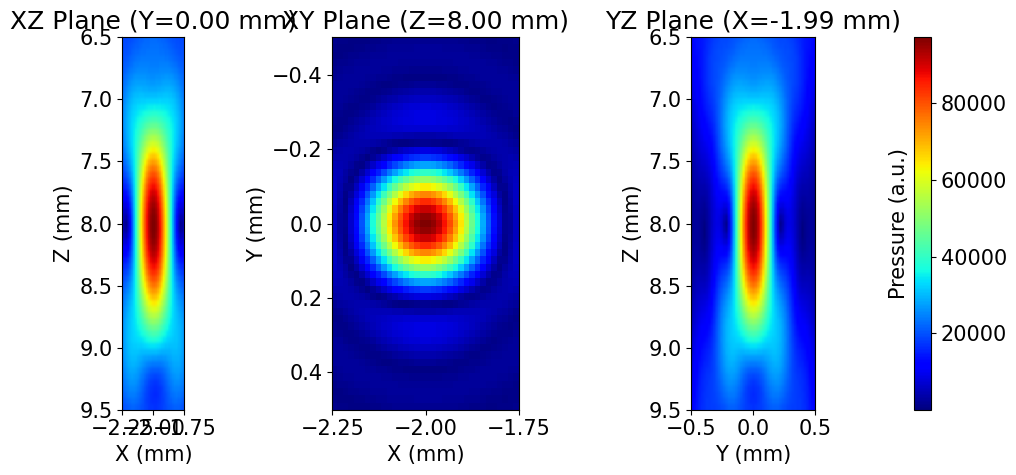

Taking slice (-1.9924242424242424,0.0,8.0) => x_ind, y_ind, z_ind = 18/34, 26/51, 31/61


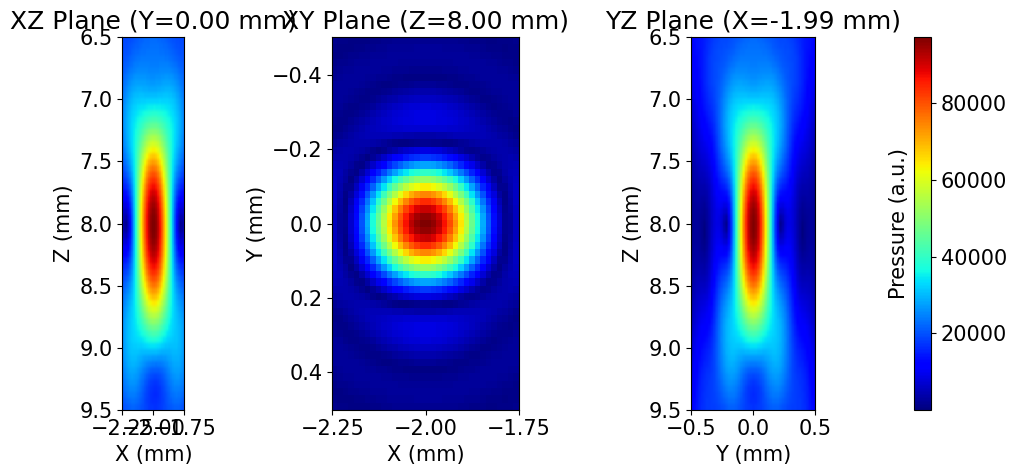

Taking slice (-1.9924242424242424,0.0,8.0) => x_ind, y_ind, z_ind = 18/34, 26/51, 31/61


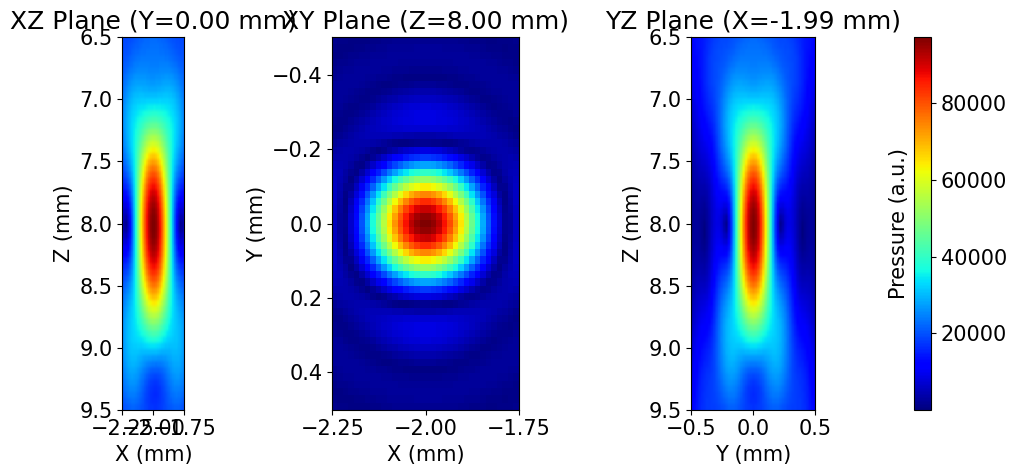

In [532]:
pyfield.plot_field_planes(x1, y1, z1, p_matrixfield1)
pyfield.plot_field_planes(x2, y2, z2, p_matrixfield2)
pyfield.plot_field_planes(x3, y3, z3, p_matrixfield3)

# 4. Methods comparison

## 4.1. Theoretical performance

In the Naive approach, each patch $m$ is evaluated by filling the trapezoid over all its nonzero time samples. If we suppose that on average a trapezoid spans a fraction of the total temporal grid, corresponding to $\overline{\Delta k}$ samples, then, for $P$ field points, the computation time (CT) is on the order of

$$
CT(\text{Naive}) \sim O(P \cdot M \cdot \overline{\Delta k}) \tag{29}
$$

For clarity, consider the case of a single field point ($P=1$):

$$
CT(\text{Naive}_{(P=1)}) \sim O(M \cdot \overline{\Delta k}) \tag{30}
$$

In contrast, the SDI formulation (see Eq. [24]) avoids filling entire trapezoids. Instead, each patch contributes exactly eight Dirac deltas, requiring

$$
CT\left(\sum_{m}^{M} \Delta\delta(t-\tau_e)\right) \sim O(8M)
$$

at the expense of adding the cost of the two integrations over time each with $\sim O(T)$. Hence,

$$
CT(\text{SDI}_{(P=1)}) \sim O(8M + 2T) \tag{31}
$$

In general, the naive algorithm is faster only if

$$
M \cdot \overline{\Delta k} \ll 8M + 2T \tag{32}
$$

Which leads to

$$
\overline{\Delta k} \ll 8 + \frac{2T}{M} \tag{33}
$$

A visualization of of the distribution of $ \Delta k$ is in function of field points and transducer geometry can be seen in the 4th section

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pyfield.utilities import plot_deltak_distribution
from pyfield.psimulation import PyField
from pyfield.transducers import Domino, Zeus_Matrix
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [99]:
nxy = 41
x_extent_mm = [-10, 10]
y_extent_mm = [-10, 10]
z_extent_mm = [3, 13]

x = np.linspace(x_extent_mm[0], x_extent_mm[1], nxy)
y = np.linspace(y_extent_mm[0], y_extent_mm[1], nxy)

nz = nxy
z = np.linspace(z_extent_mm[0], z_extent_mm[1], nz)

field_points = np.zeros(((nxy+nxy+nz),3))

point_counter = 0

for x_i in range(nxy):
    field_points[point_counter,:] = np.array([x[x_i],0,8])
    point_counter += 1

for y_i in range(nxy):
    field_points[point_counter,:] = np.array([0,y[y_i],8])
    point_counter += 1

for z_i in range(nz):
    field_points[point_counter,:] = np.array([0,0,z[z_i]])
    point_counter += 1

print(field_points.shape)

(123, 3)


In [ ]:
import pyvista as pv
from pyfield.utilities import add_transducer_mesh
import pyfield.transducers as transducers 

# ----------- Create the transducer -----------

MyTransducer = transducers.LinearArrayTransducer(
    n_elements         = 128,
    element_width_mm   = 0.108,
    element_height_mm  = 1.5,
    elevation_focus_mm = 0,
    kerf_mm            = 0.11-0.108,
    no_sub_x           = 1,
    no_sub_y           = 1,
    frequency_Hz       = 12.5*1e6,  # MHz
    )

Tx_linear_mesh = MyTransducer.get_mesh()

MyTransducer = transducers.MatrixArrayTransducer(
        N_elem_x=55,
        N_elem_y=55,
        elem_width_mm=0.29,
        elem_height_mm=0.29,
        kerf_x_mm=0.01,
        kerf_y_mm=0.01,
        no_sub_x=1,
        no_sub_y=1,
        frequency_Hz=10 * 1e6,
    )

Tx_matrix_mesh = MyTransducer.get_mesh()

# ---------- Create reference planes ----------
x_size = 20
y_size = 20
z_size = 10
plane_center = (0, 0, 8)

plane_direction_xz = (0, 1, 0)
plane_direction_xy = (0, 0, 1)
plane_direction_yz = (1, 0, 0)
plane_xy = pv.Plane(
    center=plane_center, direction=plane_direction_xy, i_size=x_size, j_size=y_size
)
plane_xz = pv.Plane(
    center=plane_center, direction=plane_direction_xz, i_size=z_size, j_size=x_size
)
plane_yz = pv.Plane(
    center=plane_center, direction=plane_direction_yz, i_size=z_size, j_size=y_size
)

# --- Draw some vectors at field points ---
pointx_start = np.array([x_extent_mm[0], 0 , 8])
pointx_end = np.array([x_extent_mm[1], 0 , 8])
pointy_start = np.array([0, y_extent_mm[0] , 8])
pointy_end = np.array([0, y_extent_mm[1] , 8])
pointz_start = np.array([0, 0 , z_extent_mm[0]])
pointz_end = np.array([0, 0 , z_extent_mm[1]])
# compute direction unit vectors and lengths
dirx = pointx_end - pointx_start
distx = np.linalg.norm(dirx)
dirx_u = dirx/distx if distx>0 else np.array([1.0,0.0,0.0])

diry = pointy_end - pointy_start
disty = np.linalg.norm(diry)
diry_u = diry/disty if disty>0 else np.array([0.0,1.0,0.0])

dirz = pointz_end - pointz_start
distz = np.linalg.norm(dirz)
dirz_u = dirz/distz if distz>0 else np.array([0.0,0.0,1.0])

# create arrows: direction must be unit vector, scale = desired length


arrow_x = pv.Arrow(start=pointx_start, direction=dirx_u, tip_length=0.1*distz/distx, tip_radius=0.02*distz/distx, shaft_radius=0.01*distz/distx, scale=distx)
arrow_y = pv.Arrow(start=pointy_start, direction=diry_u, tip_length=0.1*distz/disty, tip_radius=0.02*distz/disty, shaft_radius=0.01*distz/disty, scale=disty)
arrow_z = pv.Arrow(start=pointz_start, direction=dirz_u, tip_length=0.1, tip_radius=0.02, shaft_radius=0.01, scale=distz)

# ---------- 3D Plot -----------

plotter = pv.Plotter(window_size=(2000, 1000), notebook=True)

plotter.add_mesh(arrow_x, color='red', label='X axis')
plotter.add_mesh(arrow_y, color='blue', label='Y axis')
plotter.add_mesh(arrow_z, color='green', label='Z axis')

plotter.add_mesh(plane_xy, color="lightgray", opacity=0.2)
plotter.add_mesh(plane_xz, color="lightgray", opacity=0.2)
plotter.add_mesh(plane_yz, color="lightgray", opacity=0.2)

# plotter = add_transducer_mesh(Tx_linear_mesh, plotter=plotter)
plotter = add_transducer_mesh(Tx_matrix_mesh, plotter=plotter)

plotter.camera.up = (0, 0, -1)

# Linear array
# plotter.camera_position = [(23.51729008645421, 19.244944714798255, -15.24990807152367),
#  (4.392042711044697, -3.231804835989303, 7.247811600778641),
#  (-0.44174759699450816, -0.41844018027080226, -0.7935785254683473)]
# Matrix array
plotter.camera_position = [(28.19525643186872, 21.270901342212873, -7.22944272501991),
 (4.457462461322153, -3.6063969386306103, 6.726341582956502),
 (-0.279388017813348, -0.2530170934662707, -0.9262422393284648)]
plotter.show(jupyter_backend='static')



LinearArrayTransducer initialized in 0.0000 seconds.
MatrixArrayTransducer initialized with 3025 elements and 3025 patches.

Transducer initialized in 0.0449 seconds.


In [9]:
linear_array_probe = Domino()
matrix_array_probe = Zeus_Matrix()

linear_field = PyField(linear_array_probe)
matrix_field = PyField(matrix_array_probe)

_ = linear_field.compute_sir(field_points*1e-3, method = 'naive')
_ = matrix_field.compute_sir(field_points*1e-3, method = 'naive')



LinearArrayTransducer initialized in 0.0080 seconds.
MatrixArrayTransducer initialized with 3025 elements and 12100 patches.

Transducer initialized in 0.0720 seconds.
Min distance must be >> w^2/(4*lambda): 0.0457 mm
Min distance must be >> w^2/(4*lambda): 0.0341 mm

Computing SIR for 123 points and 1280 patches with method naive...
Min distance: 3.00 mm, Max distance: 18.77 mm
Computed time grid from 1.86 us to 12.28 us, with 2083 samples in 0.00 seconds.
Transducer SIR computed in 0.006 seconds...

Computing SIR for 123 points and 12100 patches with method naive...
Min distance: 3.00 mm, Max distance: 21.47 mm
Computed time grid from 1.86 us to 14.04 us, with 2437 samples in 0.00 seconds.
Transducer SIR computed in 0.009 seconds...


last simulation characteristics: M = 1280, P = 123, T = 2083
mean_delta_k : 11.597103658536586, and 8+2T/M : 11.2546875


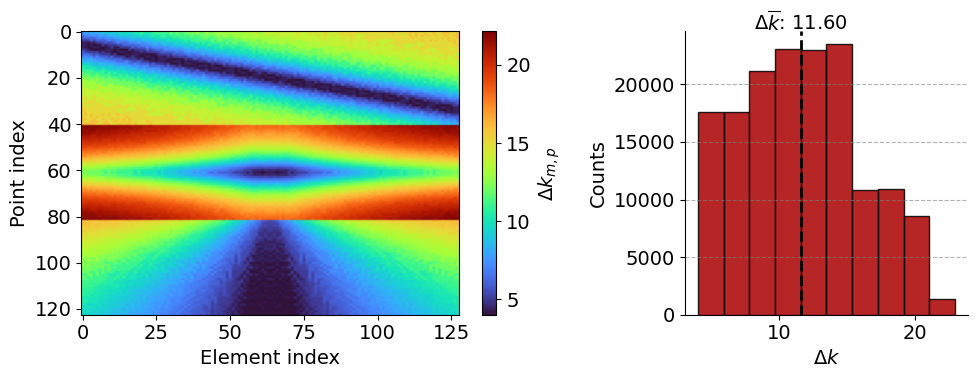

In [146]:
fig_folder = "Draft/Figures/"
plt.rcParams.update({"font.size": 14})
plt.rcParams["font.weight"] = "normal"
fig = plot_deltak_distribution(linear_field, cmap = "turbo", hist_color = "#AB0000E8", figsize = (10,4))
fig.savefig(fig_folder + "deltak_linear", dpi = 1000)

last simulation characteristics: M = 12100, P = 123, T = 2437
mean_delta_k : 17.546518847006652, and 8+2T/M : 8.402809917355372


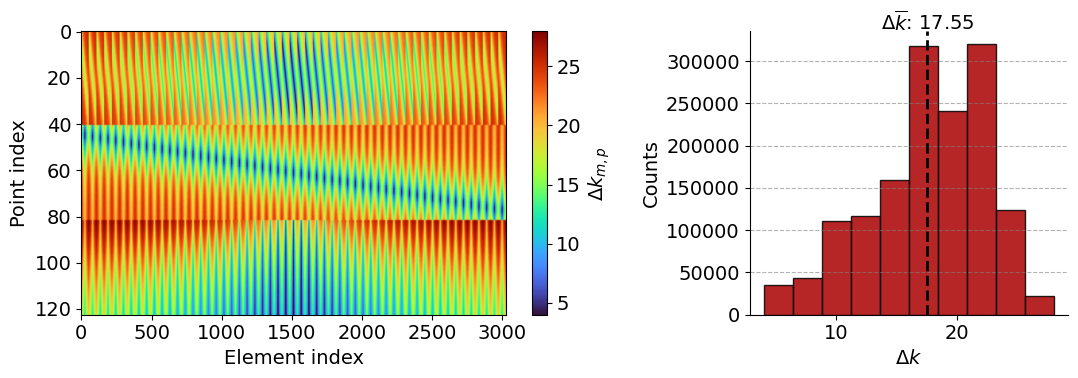

In [147]:
fig = plot_deltak_distribution(matrix_field)
fig.savefig(fig_folder + "deltak_matrix", dpi = 1000)

last simulation characteristics: M = 12100, P = 123, T = 2437
mean_delta_k : 17.546518847006652, and 8+2T/M : 8.402809917355372


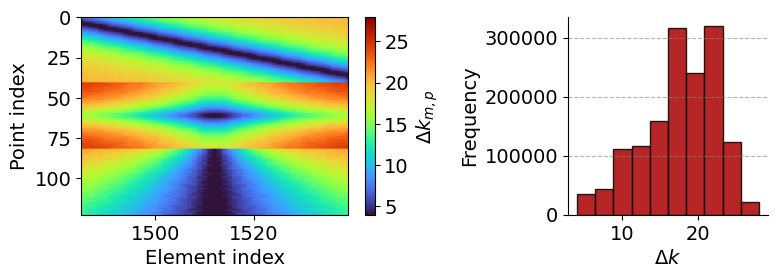

In [13]:
x0 = 1485
y0 = 0
fig = plot_deltak_distribution(matrix_field, xlim= (x0,x0+55-1), figsize = (8,3))
fig.savefig(fig_folder + "deltak_matrix_zoom", dpi = 1000)

## 4.2. Compare Methods Pressure Fields

Let's examine the difference between both results

### 4.2.1. Linear array

In [ ]:
diff_linear_field = p_linearfield2 - p_linearfield1
diff_linear_auto_field = p_linearfield3 - p_linearfield1

print(f"max_values Naive and SDI: {p_linearfield1.max()}, {p_linearfield2.max()}")

max_idx = np.unravel_index(np.argmax(diff_linear_field), diff_linear_field.shape)
min_idx = np.unravel_index(np.argmin(diff_linear_field), diff_linear_field.shape)
print(f"Max difference between SDI and naive method at index {max_idx}, value: {diff_linear_field[max_idx]}, relative: {diff_linear_field[max_idx]/p_linearfield1[max_idx]*100:.2f} %") 
print(f"Min difference between SDI and naive method at index {min_idx}, value: {diff_linear_field[min_idx]}, relative: {diff_linear_field[min_idx]/p_linearfield1[min_idx]*100:.2f} %")

point_max_diff = np.array([x1[max_idx[0]], y1[max_idx[1]], z1[max_idx[2]]])
point_min_diff = np.array([x1[min_idx[0]], y1[min_idx[1]], z1[min_idx[2]]])
print(f"Point of max difference at {point_max_diff} mm")
print(f"Point of min difference at {point_min_diff} mm")

print("DIFFERENCE BETWEEN SDI AND NAIVE METHOD:")
pyfield.plot_field_planes(x2, y2, z2,diff_linear_field/p_linearfield1.max()*100, vmin = -0.1, vmax = 0.1, label = 'Relative difference (%)', centered_to_max=True)
print("DIFFERENCE BETWEEN AUTO AND NAIVE METHOD:")
pyfield.plot_field_planes(x3, y3, z3,diff_linear_auto_field/p_linearfield1.max()*100, vmin = -0.1, vmax = 0.1, label = 'Relative difference (%)', centered_to_max=True)

NameError: name 'p_linearfield2' is not defined

In [ ]:
_, h_naive_max = linear_field.compute_sir(point_max_diff*1e-3, method = 'naive')
_, h_sdi_max = linear_field.compute_sir(point_max_diff*1e-3, method = 'sdi')
_, h_auto_max = linear_field.compute_sir(point_max_diff*1e-3, method = 'auto')

_, h_naive_min = linear_field.compute_sir(point_min_diff*1e-3, method = 'naive')
_, h_sdi_min = linear_field.compute_sir(point_min_diff*1e-3, method = 'sdi')
_, h_auto_min = linear_field.compute_sir(point_min_diff*1e-3, method = 'auto')



Computing SIR for 1 points and 1280 patches with method naive...
Min distance: 7.95 mm, Max distance: 12.00 mm
Computed time grid from 5.08 us to 7.88 us, with 560 samples in 0.00 seconds.
Transducer SIR computed in 0.000 seconds...

Computing SIR for 1 points and 1280 patches with method sdi...
Min distance: 7.95 mm, Max distance: 12.00 mm
Computed time grid from 5.08 us to 7.88 us, with 560 samples in 0.00 seconds.
Transducer SIR computed in 0.000 seconds...

Computing SIR for 1 points and 1280 patches with method auto...
Min distance: 7.95 mm, Max distance: 12.00 mm
Computed time grid from 5.08 us to 7.88 us, with 560 samples in 0.00 seconds.
Transducer SIR computed in 0.000 seconds...

Computing SIR for 1 points and 1280 patches with method naive...
Min distance: 8.20 mm, Max distance: 12.15 mm
Computed time grid from 5.24 us to 7.97 us, with 547 samples in 0.00 seconds.
Transducer SIR computed in 0.000 seconds...

Computing SIR for 1 points and 1280 patches with method sdi...
Min

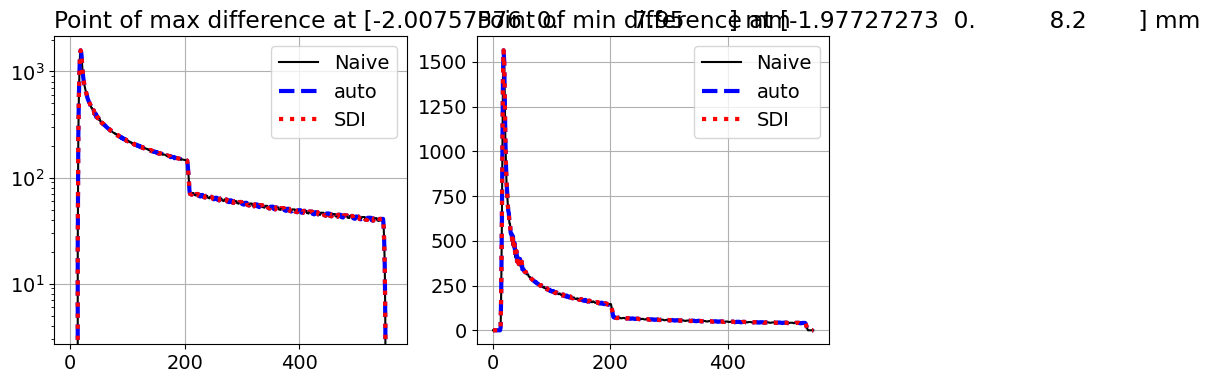

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10, 4))
ax = ax.flatten()
k = 0
ax[k].plot(h_naive_max, color = 'k', lw=1.5, label = 'Naive', linestyle = 'solid')
ax[k].plot(h_auto_max, color = 'blue', lw=3, label = 'auto', linestyle = 'dashed')
ax[k].plot(h_sdi_max, color = 'red', lw=3, label = 'SDI', linestyle = 'dotted')
# ax[k].set_xlim([300, 400])
ax[k].set_title(f'Point of max difference at {point_max_diff} mm', loc='left')
ax[k].set_yscale('log')
ax[k].grid('minor')
ax[k].legend()
k += 1
ax[k].plot(h_naive_min, color = 'k', lw=1.5, label = 'Naive', linestyle = 'solid')
ax[k].plot(h_auto_min, color = 'blue', lw=3, label = 'auto', linestyle = 'dashed')
ax[k].plot(h_sdi_min, color = 'red', lw=3, label = 'SDI', linestyle = 'dotted')
# ax[k].set_xlim([300, 400])
ax[k].set_title(f'Point of min difference at {point_min_diff} mm', loc='left')
# ax[k].set_yscale('log')
ax[k].grid('minor')
ax[k].legend()



### 4.2.2. Matrix array

max_values Naive and SDI: 97141.9140625, 97140.8046875
Max difference between SDI and naive method at index (np.int64(12), np.int64(26), np.int64(24)), value: 20.0859375, relative: 0.03 %
Min difference between SDI and naive method at index (np.int64(11), np.int64(28), np.int64(29)), value: -18.98828125, relative: -0.03 %
Point of max difference at [-2.06818182  0.02        7.7       ] mm
Point of min difference at [-2.08333333  0.06        7.95      ] mm
Taking slice (-1.9924242424242424,0.0,8.0) => x_ind, y_ind, z_ind = 18/34, 26/51, 31/61


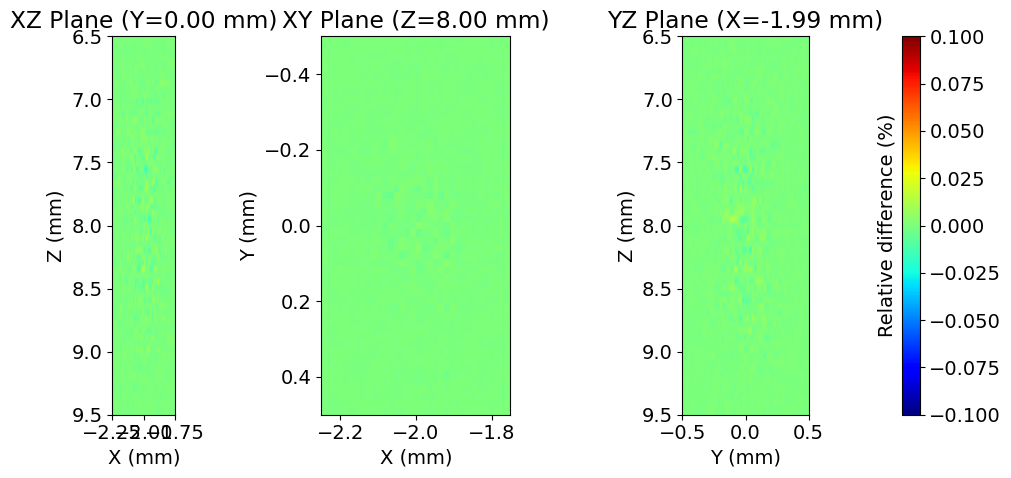

Taking slice (-1.9924242424242424,0.0,8.0) => x_ind, y_ind, z_ind = 18/34, 26/51, 31/61


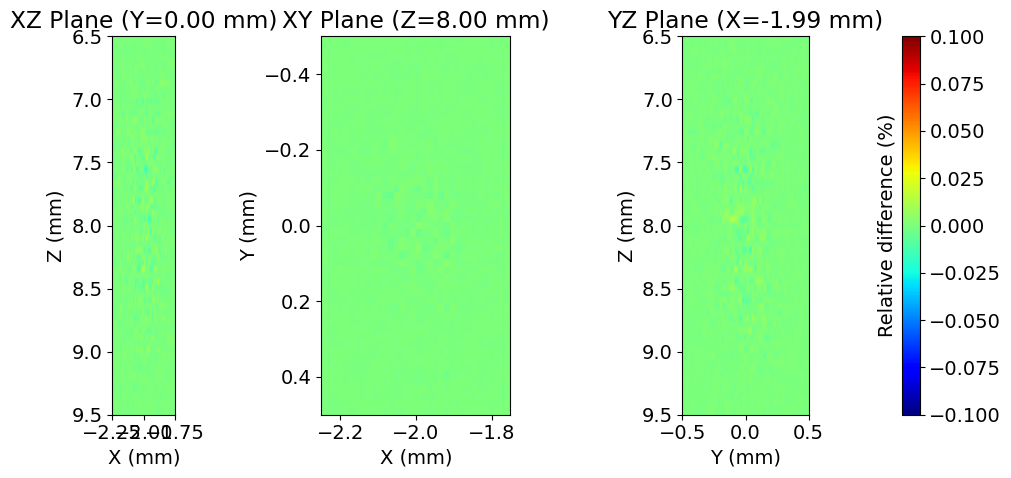

In [ ]:
diff_matrix_field = p_matrixfield2 - p_matrixfield1
diff_matrix_auto_field = p_matrixfield3 - p_matrixfield1

print(f"max_values Naive and SDI: {p_matrixfield1.max()}, {p_matrixfield2.max()}")

max_idx_matrix = np.unravel_index(np.argmax(diff_matrix_field), diff_matrix_field.shape)
min_idx_matrix = np.unravel_index(np.argmin(diff_matrix_field), diff_matrix_field.shape)
print(f"Max difference between SDI and naive method at index {max_idx_matrix}, value: {diff_matrix_field[max_idx_matrix]}, relative: {diff_matrix_field[max_idx_matrix]/p_matrixfield1[max_idx_matrix]*100:.2f} %") 
print(f"Min difference between SDI and naive method at index {min_idx_matrix}, value: {diff_matrix_field[min_idx_matrix]}, relative: {diff_matrix_field[min_idx_matrix]/p_matrixfield1[min_idx_matrix]*100:.2f} %") 

point_max_diff_matrix = np.array([x1[max_idx_matrix[0]], y1[max_idx_matrix[1]], z1[max_idx_matrix[2]]])
point_min_diff_matrix = np.array([x1[min_idx_matrix[0]], y1[min_idx_matrix[1]], z1[min_idx_matrix[2]]])
print(f"Point of max difference at {point_max_diff_matrix} mm")
print(f"Point of min difference at {point_min_diff_matrix} mm")

pyfield.plot_field_planes(x2, y2, z2, diff_matrix_field/p_matrixfield1.max()*100, vmin = -0.1, vmax = 0.1, label = 'Relative difference (%)')
pyfield.plot_field_planes(x3, y3, z3, diff_matrix_auto_field/p_matrixfield1.max()*100, vmin = -0.1, vmax = 0.1, label = 'Relative difference (%)')

In [ ]:
_, h_naive_max_matrix =  matrix_field.compute_sir(point_max_diff_matrix*1e-3, method = 'naive')
_, h_sdi_max_matrix = matrix_field.compute_sir(point_max_diff_matrix*1e-3, method = 'sdi')
_, h_auto_max_matrix = matrix_field.compute_sir(point_max_diff_matrix*1e-3, method = 'auto')

_, h_naive_min_matrix = matrix_field.compute_sir(point_min_diff_matrix*1e-3, method = 'naive')
_, h_sdi_min_matrix = matrix_field.compute_sir(point_min_diff_matrix*1e-3, method = 'sdi')
_, h_auto_min_matrix = matrix_field.compute_sir(point_min_diff_matrix*1e-3, method = 'auto')


Computing SIR for 1 points and 12100 patches with method naive...
Min distance: 7.70 mm, Max distance: 15.21 mm
Computed time grid from 4.91 us to 9.97 us, with 1013 samples in 0.00 seconds.
Transducer SIR computed in 0.002 seconds...

Computing SIR for 1 points and 12100 patches with method sdi...
Min distance: 7.70 mm, Max distance: 15.21 mm
Computed time grid from 4.91 us to 9.97 us, with 1013 samples in 0.00 seconds.
Transducer SIR computed in 0.000 seconds...

Computing SIR for 1 points and 12100 patches with method auto...
Min distance: 7.70 mm, Max distance: 15.21 mm
Computed time grid from 4.91 us to 9.97 us, with 1013 samples in 0.00 seconds.
Transducer SIR computed in 0.000 seconds...

Computing SIR for 1 points and 12100 patches with method naive...
Min distance: 7.95 mm, Max distance: 15.37 mm
Computed time grid from 5.07 us to 10.07 us, with 1001 samples in 0.00 seconds.
Transducer SIR computed in 0.001 seconds...

Computing SIR for 1 points and 12100 patches with method 

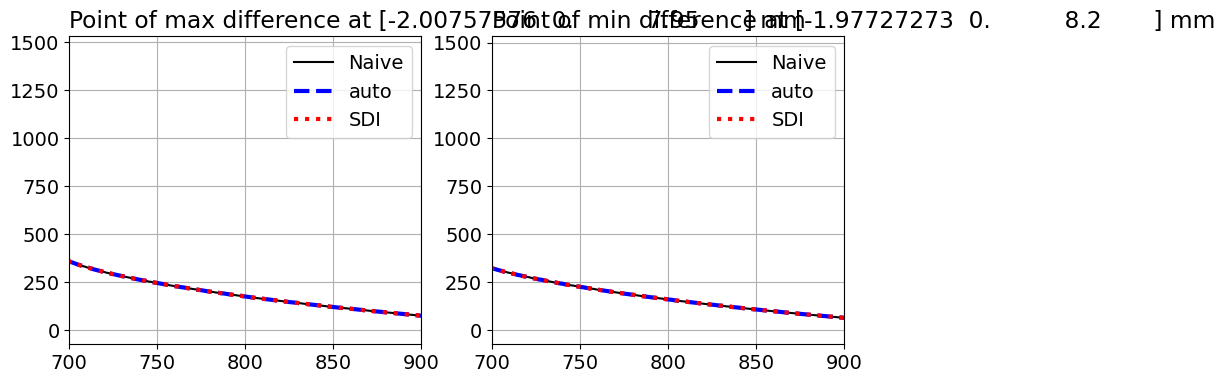

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10, 4))
ax = ax.flatten()
k = 0
ax[k].plot(h_naive_max_matrix, color = 'k', lw=1.5, label = 'Naive', linestyle = 'solid')
ax[k].plot(h_auto_max_matrix, color = 'blue', lw=3, label = 'auto', linestyle = 'dashed')
ax[k].plot(h_sdi_max_matrix, color = 'red', lw=3, label = 'SDI', linestyle = 'dotted')
ax[k].set_xlim([700, 900])
ax[k].set_title(f'Point of max difference at {point_max_diff} mm', loc='left')
ax[k].grid('minor')
ax[k].legend()
k += 1
ax[k].plot(h_naive_min_matrix, color = 'k', lw=1.5, label = 'Naive', linestyle = 'solid')
ax[k].plot(h_auto_min_matrix, color = 'blue', lw=3, label = 'auto', linestyle = 'dashed')
ax[k].plot(h_sdi_min_matrix, color = 'red', lw=3, label = 'SDI', linestyle = 'dotted')
ax[k].set_xlim([700, 900])
ax[k].set_title(f'Point of min difference at {point_min_diff} mm', loc='left')
ax[k].grid('minor')
ax[k].legend()